# Neural Network (NN1)

**Purpose:** This notebook implements the NN1 neural network architecture from Christensen, Siggaard, 
and Veliyev (2023) on the MHAR feature set (RVD, RVW, RVM) for the EURO STOXX 50 index 
over the period 1999–2020. We follow the paper's exact specification for the network 
architecture, activation function, optimizer, and regularization techniques. We extend 
the paper by adopting a monthly rolling window estimation scheme, re-estimating the 
network every 22 trading days rather than using a fixed window. This ensures a fair 
apples-to-apples comparison with the HAR model which re-estimates daily. We adapt three 
hyperparameters — ensemble size, maximum epochs, and early stopping patience — to ensure 
computational feasibility, while keeping all other hyperparameters identical to the paper.

## 1.1 Loading Data

We load the MALL dataset which contains all predictor variables and the target variable 
$RV_{t+1}$ for the EURO STOXX 50 index over the period 1999–2020. The dataset was 
constructed from 1-minute intraday price data and includes both the MHAR feature set 
(RVD, RVW, RVM) and the extended MALL feature set with macroeconomic and market variables. 
The target variable RV_target represents next day's realized variance $RV_{t+1}$, already 
constructed and saved in the MALL dataset.

In [39]:
# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5488, 30)
Date range: 1999-01-05 to 2020-08-05
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,CISS,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000078,0.000093,0.000129,-9.462355,-9.288024,-8.958306,0.000046,0.000032,0.000000,-0.000682,...,0.2085,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000058
1999-01-06,0.000058,0.000092,0.000123,-9.760055,-9.290171,-9.005038,0.000043,0.000014,0.000000,-0.000682,...,0.2214,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000139
1999-01-07,0.000139,0.000102,0.000121,-8.877543,-9.192627,-9.023153,0.000072,0.000068,-0.015530,-0.003788,...,0.2254,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000108
1999-01-08,0.000108,0.000106,0.000112,-9.130603,-9.148418,-9.097084,0.000055,0.000053,-0.003409,-0.003788,...,0.2297,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000166
1999-01-11,0.000166,0.000110,0.000110,-8.702667,-9.116188,-9.115384,0.000076,0.000090,-0.019561,-0.007700,...,0.2583,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000115


## 2.1 Imports

We import the necessary libraries for data handling, numerical computation, and neural 
network estimation. We use TensorFlow and Keras for the network implementation, following 
the deep learning framework used in the paper. We set random seeds for both NumPy and 
TensorFlow to ensure reproducibility of results across runs.

In [69]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.16.2
Keras version: 3.10.0


## 3. Data Split
### 3.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set (70%), 
validation set (10%), and test set (20%). The training set is used to estimate the 
network weights, the validation set is used for early stopping and ensemble selection, 
and the test set is reserved exclusively for out-of-sample evaluation. No estimation 
or tuning is conducted on the test set. This split is identical to the one used in 
our HAR model implementation, ensuring a fair comparison between the two approaches.

In [72]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

print(f"Total observations: {n}")
print(f"\nTrain:      {MALL.index[0].date()} to {MALL.index[n_train-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {MALL.index[n_train].date()} to {MALL.index[n_train+n_val-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {MALL.index[n_train+n_val].date()} to {MALL.index[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5488

Train:      1999-01-05 to 2014-02-25 (3841 obs, 70.0%)
Validation: 2014-02-26 to 2016-04-19 (548 obs, 10.0%)
Test:       2016-04-20 to 2020-08-05 (1099 obs, 20.0%)


## 4. Feature Set Construction and Standardization

We use the MHAR feature set consisting of the three standard HAR predictors: daily (RVD), 
weekly (RVW), and monthly (RVM) realized variance. Following Christensen et al. (2023), 
all inputs and the target variable are standardized by subtracting the training set mean 
and dividing by the training set standard deviation prior to estimation. Crucially, we 
compute the standardization parameters exclusively from the training set and apply them 
consistently across the full dataset, ensuring no look-ahead bias is introduced. For the 
rolling window estimation, we scale the full dataset upfront using these fixed training 
set parameters. The target variable is $RV_{t+1}$, represented by RV_target in our dataset.

In [75]:
# Define target and MHAR feature set
y      = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

# Split into train, validation and test sets
X_train = X_MHAR[:n_train]
X_val   = X_MHAR[n_train:n_train + n_val]
X_test  = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val   = y[n_train:n_train + n_val]
y_test  = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
y_mean = y_train.mean()
y_std  = y_train.std()

# Scale full dataset using training set parameters
# This is required for the rolling window estimation
X_scaled = (X_MHAR - X_mean) / X_std
y_scaled = (y      - y_mean) / y_std

# Also store scaled train/val/test splits for verification
X_train_scaled = X_scaled[:n_train]
X_val_scaled   = X_scaled[n_train:n_train + n_val]
X_test_scaled  = X_scaled[n_train + n_val:]

y_train_scaled = y_scaled[:n_train]
y_val_scaled   = y_scaled[n_train:n_train + n_val]
y_test_scaled  = y_scaled[n_train + n_val:]

print(f"Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y_scaled.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Validation set: X={X_val_scaled.shape},   y={y_val_scaled.shape}")
print(f"Test set:       X={X_test_scaled.shape},  y={y_test_scaled.shape}")
print(f"\nStandardization parameters from training set:")
print(f"  X mean: {X_mean}")
print(f"  X std:  {X_std}")
print(f"  y mean: {y_mean:.6e}")
print(f"  y std:  {y_std:.6e}")
print(f"\nVerification — training set after standardization:")
print(f"  X mean (should be ~0): {X_train_scaled.mean(axis=0).round(6)}")
print(f"  X std  (should be ~1): {X_train_scaled.std(axis=0).round(6)}")
print(f"  y mean (should be ~0): {y_train_scaled.mean():.6f}")
print(f"  y std  (should be ~1): {y_train_scaled.std():.6f}")

Feature set: RVD, RVW, RVM

Full dataset:   X=(5488, 3), y=(5488,)
Training set:   X=(3841, 3), y=(3841,)
Validation set: X=(548, 3),   y=(548,)
Test set:       X=(1099, 3),  y=(1099,)

Standardization parameters from training set:
  X mean: [0.00016338 0.00016341 0.00016349]
  X std:  [0.0002562  0.0002207  0.00019419]
  y mean: 1.633669e-04
  y std:  2.562095e-04

Verification — training set after standardization:
  X mean (should be ~0): [ 0.  0. -0.]
  X std  (should be ~1): [1. 1. 1.]
  y mean (should be ~0): 0.000000
  y std  (should be ~1): 1.000000


## 5. NN1 Architecture

We implement the NN1 architecture from Christensen et al. (2023), which follows a 
geometric pyramid structure with a single hidden layer containing 2 neurons. We use 
Leaky ReLU activation with a negative slope of 0.01, following the paper's choice of 
activation function which allows gradient-based learning even when activations are 
negative. Weights are initialized using the Glorot normal initializer (Xavier 
initialization), which draws from a truncated normal distribution scaled to preserve 
the variance of activations across layers. We apply a dropout rate of 0.2 (keep rate 
of 0.8) during training to prevent overfitting, consistent with the paper. The output 
layer uses linear activation since this is a regression problem. The network is 
compiled with the Adam optimizer at a fixed learning rate of 0.001 and MSE loss, 
identical to the paper's specification.

In [78]:
def build_NN1(input_dim=3, seed=None):
    """
    NN1 architecture following Christensen et al. (2023):
    
    Architecture:
        - Input layer:  input_dim neurons (3 for MHAR)
        - Hidden layer: 2 neurons, Leaky ReLU (c=0.01), Glorot normal init
        - Dropout:      rate=0.2 (keep rate=0.8 as in paper)
        - Output layer: 1 neuron, linear activation
    
    Optimizer:   Adam, learning rate=0.001
    Loss:        Mean Squared Error
    """
    if seed is not None:
        tf.random.set_seed(seed)
    
    initializer = keras.initializers.GlorotNormal(seed=seed)
    
    model = keras.Sequential([
        # Input
        keras.Input(shape=(input_dim,)),
        # Hidden layer: 2 neurons with Leaky ReLU activation
        layers.Dense(
            2,
            kernel_initializer=initializer,
            bias_initializer="zeros"
        ),
        layers.LeakyReLU(negative_slope=0.01),
        # Dropout: 20% dropout rate (80% keep rate as in paper)
        layers.Dropout(rate=0.2),
        # Output layer: linear activation for regression
        layers.Dense(
            1,
            kernel_initializer=initializer,
            bias_initializer="zeros",
            activation="linear"
        )
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    
    return model

# Print model summary to verify architecture
test_model = build_NN1(input_dim=3, seed=0)
test_model.summary()
print(f"\nVerification of parameter count:")
print(f"  Input -> Hidden: 3 inputs x 2 neurons + 2 bias = 8 parameters")
print(f"  Hidden -> Output: 2 inputs x 1 neuron + 1 bias = 3 parameters")
print(f"  Total: 11 parameters")

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_42 (LeakyReLU)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)


Verification of parameter count:
  Input -> Hidden: 3 inputs x 2 neurons + 2 bias = 8 parameters
  Hidden -> Output: 2 inputs x 1 neuron + 1 bias = 3 parameters
  Total: 11 parameters


## 6. Hyperparameters

We adopt the following hyperparameters for the NN1 estimation. Three parameters are 
adapted from the paper to ensure computational feasibility on a single index setting: 
we reduce the ensemble size from 100 to 10 networks, the maximum number of epochs from 
500 to 200, and increase the early stopping patience to 50 to ensure sufficient 
convergence within the reduced epoch budget. All other hyperparameters are kept identical 
to the paper. We re-estimate the ensemble every 22 trading days (approximately one month), 
extending the paper's fixed window approach with a monthly rolling window scheme. This 
allows the network to adapt to new volatility regimes over time while remaining 
computationally feasible.

In [81]:
# Hyperparameters
n_ensemble = 10   # reduced from 100 (paper) to 10
n_best     = 3    # reduced from 10 (paper) to 3, proportionally consistent
max_epochs = 200  # reduced from 500 (paper) to 200
patience   = 50   # increased from 20 for better convergence
refit_freq = 22   # re-estimate every 22 trading days (monthly rolling window)

print("Hyperparameter summary:")
print(f"  Ensemble size:        {n_ensemble} networks (paper: 100)")
print(f"  Networks selected:    {n_best} best (paper: 10 out of 100)")
print(f"  Max epochs:           {max_epochs} (paper: 500)")
print(f"  Early stopping:       patience={patience} (paper: 100)")
print(f"  Re-estimation freq:   every {refit_freq} trading days (paper: fixed window)")
print(f"  Learning rate:        0.001 (identical to paper)")
print(f"  Dropout keep rate:    0.8 (identical to paper)")
print(f"  Batch size:           full batch (identical to paper)")
print(f"  Weight initializer:   Glorot normal (identical to paper)")
print(f"  Activation:           Leaky ReLU c=0.01 (identical to paper)")

# Estimate computational cost
n_refits   = int(np.ceil(n_test / refit_freq))
time_per_refit = 1.23  # minutes, based on earlier timing test
total_time = n_refits * time_per_refit

print(f"\nComputational cost estimate:")
print(f"  Number of refits:     {n_refits}")
print(f"  Time per refit:       ~{time_per_refit} minutes")
print(f"  Total estimated time: ~{total_time:.0f} minutes ({total_time/60:.1f} hours)")

Hyperparameter summary:
  Ensemble size:        10 networks (paper: 100)
  Networks selected:    3 best (paper: 10 out of 100)
  Max epochs:           200 (paper: 500)
  Early stopping:       patience=50 (paper: 100)
  Re-estimation freq:   every 22 trading days (paper: fixed window)
  Learning rate:        0.001 (identical to paper)
  Dropout keep rate:    0.8 (identical to paper)
  Batch size:           full batch (identical to paper)
  Weight initializer:   Glorot normal (identical to paper)
  Activation:           Leaky ReLU c=0.01 (identical to paper)

Computational cost estimate:
  Number of refits:     50
  Time per refit:       ~1.23 minutes
  Total estimated time: ~62 minutes (1.0 hours)


## 7. Monthly Rolling Window Estimation and Forecasting

We train 10 independent NN1 networks with different random seeds on a rolling window 
of fixed length equal to the combined training and validation set (4,389 observations). 
The ensemble is re-estimated every 22 trading days, with the validation portion of each 
window (last 548 observations) used for early stopping and ensemble selection. We select 
the 3 best networks based on validation MSE and average their forecasts. Between 
re-estimation dates we use the most recently estimated ensemble to generate daily 
forecasts. All forecasts are back-transformed to the original scale by reversing the 
target standardization. We apply the insanity filter of Bollerslev, Patton, and 
Quaedvlieg (2016), replacing any negative forecast with the minimum realized variance 
in the current estimation window.

In [84]:
# Rolling window size = train + validation
window_size = n_train + n_val
forecasts_NN1 = []
dates_test    = []
best_models   = None
last_refit    = -refit_freq  # force refit on first iteration

start_time = time.time()

for i in range(n_test):

    # Re-estimate ensemble every refit_freq days
    if i - last_refit >= refit_freq:

        # Extract rolling window of scaled data
        X_window = X_scaled[i : i + window_size]
        y_window = y_scaled[i : i + window_size]

        # Split window into train and validation
        # Use last n_val observations as validation for early stopping
        X_win_train = X_window[:-n_val]
        X_win_val   = X_window[-n_val:]
        y_win_train = y_window[:-n_val]
        y_win_val   = y_window[-n_val:]

        # Train ensemble of n_ensemble networks
        val_losses_window = []
        models_window     = []

        for j in range(n_ensemble):

            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
                verbose=0
            )

            # Input dimension tied to actual feature set size
            model = build_NN1(input_dim=X_scaled.shape[1], seed=j)
            model.fit(
                X_win_train, y_win_train,
                validation_data=(X_win_val, y_win_val),
                epochs=max_epochs,
                batch_size=len(X_win_train),
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = model.evaluate(X_win_val, y_win_val, verbose=0)
            val_losses_window.append(val_loss)
            models_window.append(model)

        # Select n_best networks based on validation MSE
        top_idx     = np.argsort(val_losses_window)[:n_best]
        best_models = [models_window[j] for j in top_idx]
        last_refit  = i

        # Progress update
        elapsed   = (time.time() - start_time) / 60
        refit_num = i // refit_freq + 1
        print(f"  Refit {refit_num:3d}/{n_refits} | "
              f"Test day {i:4d}/{n_test} | "
              f"Date: {MALL.index[i + window_size].date()} | "
              f"Best val MSE: {min(val_losses_window):.4f} | "
              f"Elapsed: {elapsed:.1f} min")

    # Generate ensemble forecast for current test day
    X_forecast = X_scaled[i + window_size].reshape(1, -1)

    preds_scaled = np.array([
        model.predict(X_forecast, verbose=0).flatten()[0]
        for model in best_models
    ])

    # Average ensemble predictions and back-transform to original scale
    forecast = preds_scaled.mean() * y_std + y_mean

    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv   = y[i : i + window_size].min()
    forecast = max(forecast, min_rv)

    forecasts_NN1.append(forecast)
    dates_test.append(MALL.index[i + window_size])

# Total time
total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_NN1)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

  Refit   1/50 | Test day    0/1099 | Date: 2016-04-20 | Best val MSE: 0.2612 | Elapsed: 1.2 min
  Refit   2/50 | Test day   22/1099 | Date: 2016-05-20 | Best val MSE: 0.2608 | Elapsed: 2.5 min
  Refit   3/50 | Test day   44/1099 | Date: 2016-06-21 | Best val MSE: 0.2655 | Elapsed: 3.7 min
  Refit   4/50 | Test day   66/1099 | Date: 2016-07-22 | Best val MSE: 0.4146 | Elapsed: 5.0 min
  Refit   5/50 | Test day   88/1099 | Date: 2016-08-23 | Best val MSE: 0.4157 | Elapsed: 6.2 min
  Refit   6/50 | Test day  110/1099 | Date: 2016-09-22 | Best val MSE: 0.4168 | Elapsed: 7.5 min
  Refit   7/50 | Test day  132/1099 | Date: 2016-10-24 | Best val MSE: 0.4188 | Elapsed: 8.8 min
  Refit   8/50 | Test day  154/1099 | Date: 2016-11-23 | Best val MSE: 0.4294 | Elapsed: 10.1 min
  Refit   9/50 | Test day  176/1099 | Date: 2016-12-23 | Best val MSE: 0.4180 | Elapsed: 11.4 min
  Refit  10/50 | Test day  198/1099 | Date: 2017-01-25 | Best val MSE: 0.4155 | Elapsed: 19.7 min
  Refit  11/50 | Test day  

## 8. Save Forecasts

We save the NN1 forecasts and MSE summary to CSV files for use in the final model 
comparison. We follow the same file structure as the HAR model to ensure consistency 
across all models.

In [88]:
# Collect results
test_dates  = MALL.index[n_train + n_val:]
results_NN1 = pd.DataFrame({
    "RV_actual":   y_test,
    "RV_forecast": forecasts_NN1
}, index=test_dates)

# Compute MSE and error metrics
mse_NN1    = np.mean((results_NN1["RV_actual"] - results_NN1["RV_forecast"])**2)
errors_NN1 = results_NN1["RV_actual"] - results_NN1["RV_forecast"]

# Save forecast path
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

# Save forecasts
results_NN1.to_csv(os.path.join(forecast_path, "forecasts_NN1.csv"))

# Save MSE summary
mse_summary_NN1 = pd.DataFrame({
    "Model":      ["NN1"],
    "MSE":        [mse_NN1],
    "RMSE":       [np.sqrt(mse_NN1)],
    "MAE":        [errors_NN1.abs().mean()],
    "Mean_Error": [errors_NN1.mean()],
}).set_index("Model")

mse_summary_NN1.to_csv(os.path.join(forecast_path, "mse_summary_NN1.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_NN1.csv ({len(results_NN1)} rows)")
print(f"  - mse_summary_NN1.csv")
print(f"\nNN1 MSE: {mse_NN1:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_NN1.csv (1099 rows)
  - mse_summary_NN1.csv

NN1 MSE: 3.564467e-08


## 9. Out-of-Sample Performance Evaluation

We evaluate the out-of-sample forecast accuracy of the NN1 model using the Mean 
Squared Error (MSE) and compare it to the HAR benchmark. Following Christensen 
et al. (2023), we report the relative MSE of the NN1 model with respect to the 
HAR model, where a value below 1 indicates that NN1 outperforms the HAR benchmark. 
We load the HAR forecasts saved from our HAR model notebook to ensure a consistent 
and fair comparison across models.

In [91]:
# Load HAR forecasts for comparison
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR   = pd.read_csv(
    os.path.join(forecast_path, "forecasts_HAR.csv"),
    index_col=0,
    parse_dates=True
)

# Load HAR MSE summary
mse_summary_HAR = pd.read_csv(
    os.path.join(forecast_path, "mse_summary_HAR.csv"),
    index_col=0
)
mse_HAR = mse_summary_HAR.loc["HAR", "MSE"]

# Compute relative MSE (NN1 / HAR)
rel_mse_NN1 = mse_NN1 / mse_HAR

# Compute error metrics for both models
errors_NN1 = results_NN1["RV_actual"] - results_NN1["RV_forecast"]
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]

# Print performance comparison
print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {'1.0000':>10}")
print(f"{'NN1':<10} {mse_NN1:>12.6e} {np.sqrt(mse_NN1):>12.6e} {errors_NN1.abs().mean():>12.6e} {errors_NN1.mean():>12.6e} {rel_mse_NN1:>10.4f}")
print("-" * 70)
print(f"\nNN1 relative MSE vs HAR: {rel_mse_NN1:.4f}")
if rel_mse_NN1 < 1:
    print(f"NN1 outperforms HAR by {(1 - rel_mse_NN1)*100:.2f}% in MSE reduction")
else:
    print(f"NN1 underperforms HAR by {(rel_mse_NN1 - 1)*100:.2f}% in MSE increase")

Out-of-sample performance (2016-04-20 to 2020-08-05):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
NN1        3.564467e-08 1.887980e-04 6.261892e-05 5.718967e-06     1.6047
----------------------------------------------------------------------

NN1 relative MSE vs HAR: 1.6047
NN1 underperforms HAR by 60.47% in MSE increase


## 10. Forecast Visualization

We plot the actual realized volatility against the NN1 forecasts over the test 
period, expressed as annualized volatility in percentage terms for ease of 
interpretation. We superimpose the HAR forecasts for direct visual comparison 
between the two models.

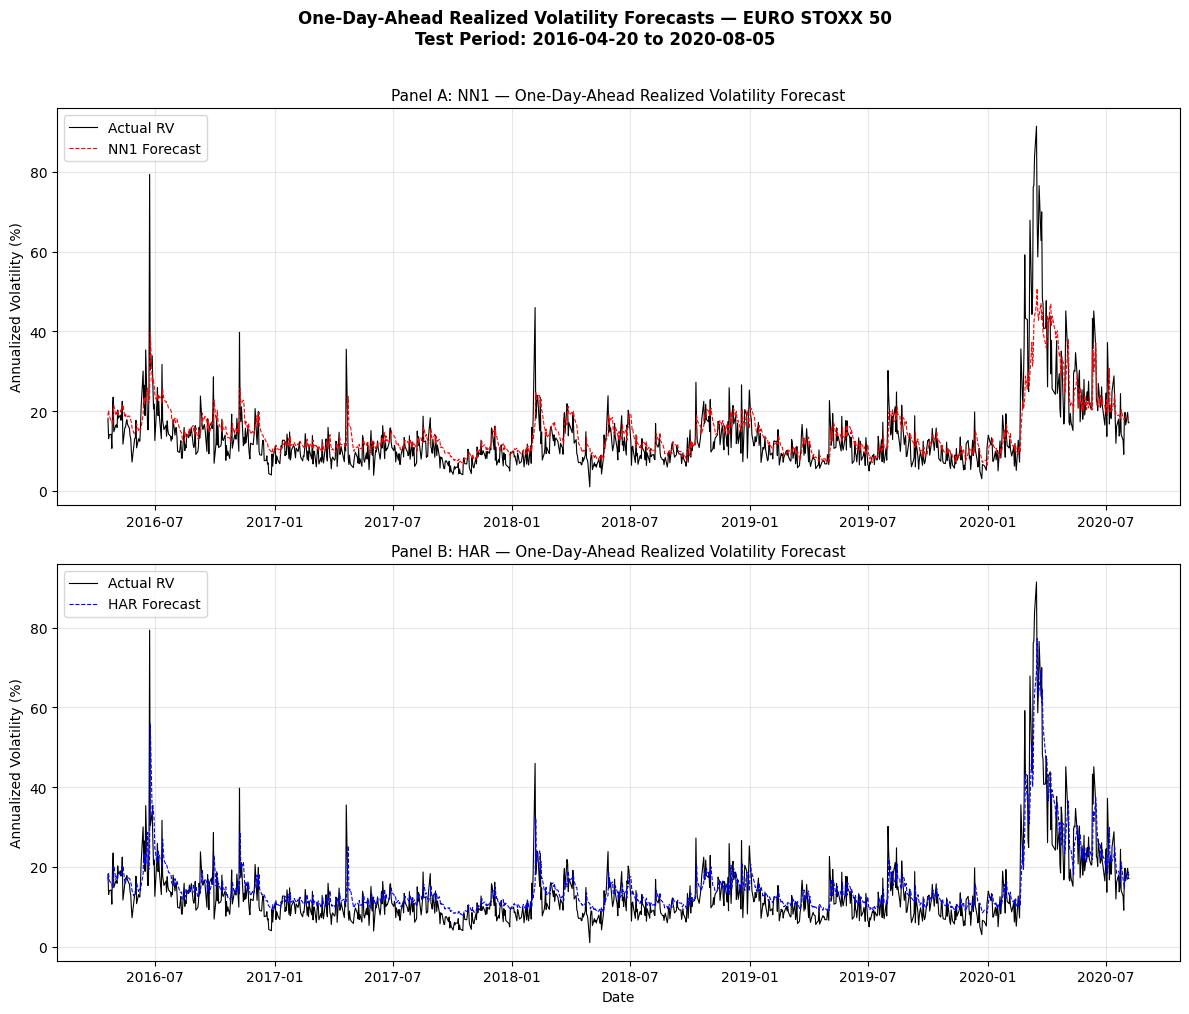

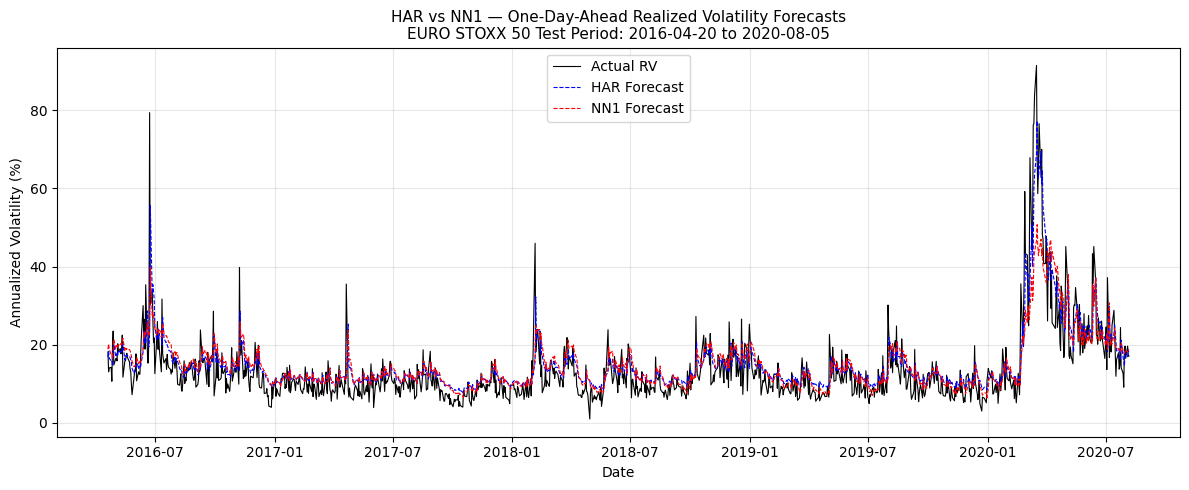

Summary of forecast errors:

Metric                        HAR          NN1
----------------------------------------------
Mean error           -4.057863e-06 5.718967e-06
RMSE                 1.490415e-04 1.887980e-04
MAE                  5.592501e-05 6.261892e-05
Relative MSE               1.0000       1.6047


In [94]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
actual      = np.sqrt(results_NN1["RV_actual"]   * 252) * 100
forecast_NN1 = np.sqrt(results_NN1["RV_forecast"] * 252) * 100
forecast_HAR = np.sqrt(results_HAR["RV_forecast"] * 252) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Panel A: NN1 vs Actual ────────────────────────────────────────────────────
axes[0].plot(actual,       label="Actual RV",    color="black", linewidth=0.8)
axes[0].plot(forecast_NN1, label="NN1 Forecast", color="red",   linewidth=0.8, linestyle="--")
axes[0].set_title("Panel A: NN1 — One-Day-Ahead Realized Volatility Forecast", fontsize=11)
axes[0].set_ylabel("Annualized Volatility (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Panel B: HAR vs Actual ────────────────────────────────────────────────────
axes[1].plot(actual,       label="Actual RV",    color="black", linewidth=0.8)
axes[1].plot(forecast_HAR, label="HAR Forecast", color="blue",  linewidth=0.8, linestyle="--")
axes[1].set_title("Panel B: HAR — One-Day-Ahead Realized Volatility Forecast", fontsize=11)
axes[1].set_ylabel("Annualized Volatility (%)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "One-Day-Ahead Realized Volatility Forecasts — EURO STOXX 50\n"
    f"Test Period: {test_dates[0].date()} to {test_dates[-1].date()}",
    fontsize=12,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

# ── Panel C: Both forecasts vs Actual ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual,        label="Actual RV",    color="black", linewidth=0.8)
ax.plot(forecast_HAR,  label="HAR Forecast", color="blue",  linewidth=0.8, linestyle="--")
ax.plot(forecast_NN1,  label="NN1 Forecast", color="red",   linewidth=0.8, linestyle="--")
ax.set_title(
    "HAR vs NN1 — One-Day-Ahead Realized Volatility Forecasts\n"
    f"EURO STOXX 50 Test Period: {test_dates[0].date()} to {test_dates[-1].date()}",
    fontsize=11
)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary statistics of forecast errors ────────────────────────────────────
print("Summary of forecast errors:")
print(f"\n{'Metric':<20} {'HAR':>12} {'NN1':>12}")
print("-" * 46)
print(f"{'Mean error':<20} {errors_HAR.mean():>12.6e} {errors_NN1.mean():>12.6e}")
print(f"{'RMSE':<20} {np.sqrt(mse_HAR):>12.6e} {np.sqrt(mse_NN1):>12.6e}")
print(f"{'MAE':<20} {errors_HAR.abs().mean():>12.6e} {errors_NN1.abs().mean():>12.6e}")
print(f"{'Relative MSE':<20} {'1.0000':>12} {rel_mse_NN1:>12.4f}")

## 11. Sub-Period Analysis

We examine whether the underperformance of NN1 relative to HAR is driven by the 
extreme volatility spike during the COVID-19 pandemic in early 2020. We split the 
test period into two sub-periods: pre-2020 (2016-04-20 to 2019-12-31) and 2020 
(2020-01-01 to 2020-08-05), and compute the MSE and relative MSE for each 
sub-period separately.

In [97]:
# Split test period into pre-2020 and 2020
pre_2020  = results_NN1.index < "2020-01-01"
in_2020   = results_NN1.index >= "2020-01-01"

# Pre-2020 performance
mse_NN1_pre  = np.mean((results_NN1.loc[pre_2020, "RV_actual"] - results_NN1.loc[pre_2020, "RV_forecast"])**2)
mse_HAR_pre  = np.mean((results_HAR.loc[pre_2020, "RV_actual"] - results_HAR.loc[pre_2020, "RV_forecast"])**2)
rel_mse_pre  = mse_NN1_pre / mse_HAR_pre

# 2020 performance
mse_NN1_2020 = np.mean((results_NN1.loc[in_2020, "RV_actual"] - results_NN1.loc[in_2020, "RV_forecast"])**2)
mse_HAR_2020 = np.mean((results_HAR.loc[in_2020, "RV_actual"] - results_HAR.loc[in_2020, "RV_forecast"])**2)
rel_mse_2020 = mse_NN1_2020 / mse_HAR_2020

# Full period
rel_mse_full = mse_NN1 / mse_HAR

print(f"Sub-period performance analysis:")
print(f"\n{'Period':<30} {'Obs':>6} {'MSE HAR':>12} {'MSE NN1':>12} {'Rel. MSE':>10}")
print("-" * 75)
print(f"{'Full (2016-04-20 to 2020-08-05)':<30} {len(results_NN1):>6} {mse_HAR:>12.6e} {mse_NN1:>12.6e} {rel_mse_full:>10.4f}")
print(f"{'Pre-2020 (2016-04-20 to 2019-12-31)':<30} {pre_2020.sum():>6} {mse_HAR_pre:>12.6e} {mse_NN1_pre:>12.6e} {rel_mse_pre:>10.4f}")
print(f"{'2020 (2020-01-01 to 2020-08-05)':<30} {in_2020.sum():>6} {mse_HAR_2020:>12.6e} {mse_NN1_2020:>12.6e} {rel_mse_2020:>10.4f}")
print("-" * 75)
print(f"\nPre-2020: NN1 {'outperforms' if rel_mse_pre < 1 else 'underperforms'} HAR by {abs(1 - rel_mse_pre)*100:.2f}%")
print(f"2020:     NN1 {'outperforms' if rel_mse_2020 < 1 else 'underperforms'} HAR by {abs(1 - rel_mse_2020)*100:.2f}%")

Sub-period performance analysis:

Period                            Obs      MSE HAR      MSE NN1   Rel. MSE
---------------------------------------------------------------------------
Full (2016-04-20 to 2020-08-05)   1099 2.221336e-08 3.564467e-08     1.6047
Pre-2020 (2016-04-20 to 2019-12-31)    947 9.828392e-09 9.039435e-09     0.9197
2020 (2020-01-01 to 2020-08-05)    152 9.937494e-08 2.014023e-07     2.0267
---------------------------------------------------------------------------

Pre-2020: NN1 outperforms HAR by 8.03%
2020:     NN1 underperforms HAR by 102.67%
